### Load libraries

In [12]:
from importlib import reload
from helpers import *
import pandas as pd

from helpers.clustering import cluster_select_representatives_from_csv, visualize_clusters
from helpers.fetch import load_data
import pandas as pd

### Clustering

Found 68 tickers across 10 clusters


/Users/giacomomaggiore/Desktop/coding/leverage-api-api/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/giacomomaggiore/Desktop/coding/leverage-api-api/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


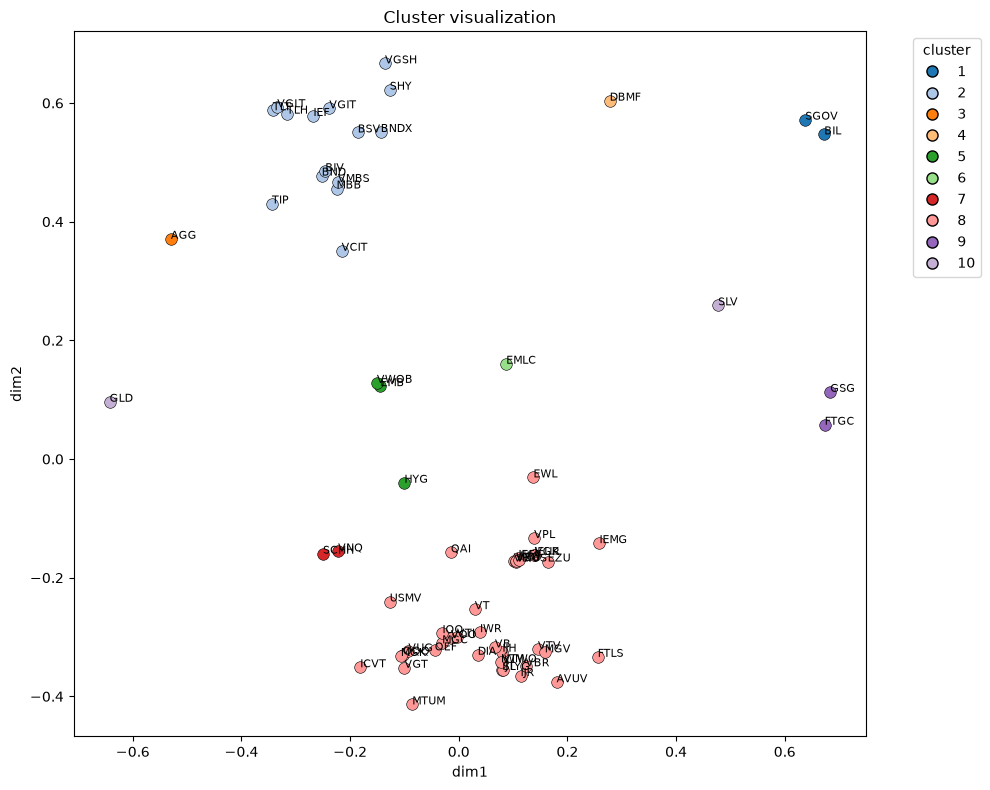

In [13]:
ETF_UNIVERSE_CSV_PATH = "data/etf_universe.csv"

# get clusters (and representatives) from the universe CSV
selected_tickers, clusters = cluster_select_representatives_from_csv(ETF_UNIVERSE_CSV_PATH, n_clusters=10)

print('Found', sum(len(v) for v in clusters.values()), 'tickers across', len(clusters), 'clusters')

# Build aligned price matrix for all tickers in the clusters (inner join on dates)
tickers = sorted([t for members in clusters.values() for t in members])
start_date = '2012-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')
prices = pd.concat([load_data(t, start_date, end_date)['adj close'].rename(t) for t in tickers], axis=1, join='inner')
returns = prices.pct_change().dropna()

# Visualize clusters using the returns correlation (MDS embedding)
fig, ax = visualize_clusters(clusters, returns=returns)


### Common window and Optimization

In [14]:
# common window for selected_tickers tickers
min_window, max_window = common_window(selected_tickers)

start_date = "2012-01-01"
end_date = pd.Timestamp.today().strftime("%Y-%m-%d")

print("Min common start date:", min_window, "Max common end date:", max_window)

LOOKBACK_YEARS = 4
REBALANCE_FREQ = "MS"
# Covariance configuration
COV_METHOD = "oas"   # 'shrunk' | 'empirical' | 'oas' | 'ewma' | 'factor'
COV_PARAMS = {"jitter": 1e-8}    


Min common start date: 2020-06-01 00:00:00 Max common end date: 2026-07-07 00:00:00


[Docs](https://pyportfolioopt.readthedocs.io/en/stable/index.html)

### Optimization Notes (PyPortfolioOpt)

- Expected returns use PyPortfolioOpt's `mean_historical_return` on adjusted-close prices (simple returns, annualized).
- Covariance is estimated from returns via PyPortfolioOpt risk models (`sample_cov`, Ledoit–Wolf, OAS, or EWMA depending on `cov_method`).
- Optimizers: `EfficientFrontier.min_volatility()` for min-variance and `EfficientFrontier.max_sharpe(risk_free_rate=rf)` for max-Sharpe.
- Long-only and fully invested constraints are enforced by default.

In [15]:
def build_portfolios(tickers, start, end, lookback_years=LOOKBACK_YEARS, freq=REBALANCE_FREQ, cov_method=None, cov_params=None):
    # Use business-month start to avoid holidays
    # offset start by lookback_years to ensure we have enough data for the first rebalance
    start = pd.Timestamp(start) + pd.DateOffset(years=lookback_years)
    rebalance_dates = pd.date_range(start, end, freq="BMS")

    # default cov settings from globals if not provided
    if cov_method is None:
        cov_method = COV_METHOD
    if cov_params is None:
        cov_params = COV_PARAMS

    mv, ms, mc = {}, {}, {}
    for dt in rebalance_dates:
        as_of = dt.date()
        mv[dt] = min_variance(tickers, as_of=as_of, timeframe_years=lookback_years, cov_method=cov_method, cov_params=cov_params)
        ms[dt] = max_sharpe(tickers, as_of=as_of, timeframe_years=lookback_years, cov_method=cov_method, cov_params=cov_params)
        mc[dt] = pd.Series({t: 1.0 if t == "VT" else 0.0 for t in tickers})

    def to_daily(d):
        df = pd.DataFrame(d).T.sort_index()
        # Start the daily index at the first available weight to avoid leading NaNs
        first = df.index.min()
        daily_idx = pd.bdate_range(first, end)
        return df.reindex(daily_idx, method="ffill")

    return {
        "min_variance": to_daily(mv),
        "max_sharpe":   to_daily(ms),
        "market_cap":   to_daily(mc),
    }

In [16]:
portfolios = build_portfolios(interest_tickers, start_date, end_date, cov_method=COV_METHOD, cov_params=COV_PARAMS)

portfolios
# portfolios["min_variance"], portfolios["max_sharpe"], portfolios["market_cap"]
# each is a DataFrame: index=business days, columns=tickers, values=weights


NameError: name 'interest_tickers' is not defined

In [ ]:
portfolios["min_variance"]

,SPY,QQQ,VT,VEA,VGSH,IEF,VGLT,GLD,TLH,BTC=F,AAPL,TSLA
2016-01-01,0.02801,0.0,0.0,0.0,0.95701,0.01373,0.0,0.0,0.0,0.0,0.00124,0.0
2016-01-04,0.02801,0.0,0.0,0.0,0.95701,0.01373,0.0,0.0,0.0,0.0,0.00124,0.0
2016-01-05,0.02801,0.0,0.0,0.0,0.95701,0.01373,0.0,0.0,0.0,0.0,0.00124,0.0
2016-01-06,0.02801,0.0,0.0,0.0,0.95701,0.01373,0.0,0.0,0.0,0.0,0.00124,0.0
2016-01-07,0.02801,0.0,0.0,0.0,0.95701,0.01373,0.0,0.0,0.0,0.0,0.00124,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-29,0.02438,0.0,0.0,0.0,0.97562,0.00000,0.0,0.0,0.0,0.0,0.00000,0.0
2026-06-30,0.02438,0.0,0.0,0.0,0.97562,0.00000,0.0,0.0,0.0,0.0,0.00000,0.0
2026-07-01,0.02829,0.0,0.0,0.0,0.97171,0.00000,0.0,0.0,0.0,0.0,0.00000,0.0
2026-07-02,0.02829,0.0,0.0,0.0,0.97171,0.00000,0.0,0.0,0.0,0.0,0.00000,0.0


In [ ]:
portfolios["max_sharpe"]

,SPY,QQQ,VT,VEA,VGSH,IEF,VGLT,GLD,TLH,BTC=F,AAPL,TSLA
2016-01-01,0.03352,0.22295,0.0,0.0,0.33056,0.0,0.0,0.00000,0.35696,0.00000,0.0,0.05602
2016-01-04,0.03352,0.22295,0.0,0.0,0.33056,0.0,0.0,0.00000,0.35696,0.00000,0.0,0.05602
2016-01-05,0.03352,0.22295,0.0,0.0,0.33056,0.0,0.0,0.00000,0.35696,0.00000,0.0,0.05602
2016-01-06,0.03352,0.22295,0.0,0.0,0.33056,0.0,0.0,0.00000,0.35696,0.00000,0.0,0.05602
2016-01-07,0.03352,0.22295,0.0,0.0,0.33056,0.0,0.0,0.00000,0.35696,0.00000,0.0,0.05602
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-29,0.00000,0.08913,0.0,0.0,0.75892,0.0,0.0,0.15195,0.00000,0.00000,0.0,0.00000
2026-06-30,0.00000,0.08913,0.0,0.0,0.75892,0.0,0.0,0.15195,0.00000,0.00000,0.0,0.00000
2026-07-01,0.00000,0.08939,0.0,0.0,0.75393,0.0,0.0,0.14168,0.00000,0.01499,0.0,0.00000
2026-07-02,0.00000,0.08939,0.0,0.0,0.75393,0.0,0.0,0.14168,0.00000,0.01499,0.0,0.00000
